In [1]:
import matplotlib.pyplot as plt
import numpy as np
import copy
import os

from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch

from common.plots import plot_anomaly_distribution, plot_fbeta_vs_threshold, plot_performance_curves, plot_reconstructions, plot_loss
from common.autoencoder.evaluation import score_images, get_reconstructions, print_metrics, score_images_variation
from common.autoencoder.training import HybridLoss, GaussianNoiseCorruption
from common.autoencoder.autoencoder import Autoencoder
from common.io import load_and_split_mnist
from common.finetuning import optimize_via_zooming_grid, optimize_fbeta_threshold
from common.config import MNIST_RAW_PATH, FIGS_DIR, DATA_WEIGHTS_DIR
from common.utils import set_seed

from typing import Tuple, Dict, Any, Callable, Type
from torch.optim import Optimizer
from torch import Tensor

SAVE_DIR = FIGS_DIR / "evaluation"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
SEED = 42
rs = set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
train_normal, val_normal, val_anomaly, test_normal, test_anomaly = load_and_split_mnist(
    mnist_path=MNIST_RAW_PATH,
    val_anomaly_digit=8,
    test_anomaly_digit=4,
    random_seed=SEED
)

print("Train splits:")
print(f"train_normal: \tX={train_normal[0].shape}, y={train_normal[1].shape}")

print("\nValidation splits:")
print(f"val_normal:   \tX={val_normal[0].shape}, y={val_normal[1].shape}")
print(f"val_anomaly:  \tX={val_anomaly[0].shape}, y={val_anomaly[1].shape}")

print("\nTest splits:")
print(f"test_normal:  \tX={test_normal[0].shape}, y={test_normal[1].shape}")
print(f"test_anomaly: \tX={test_anomaly[0].shape}, y={test_anomaly[1].shape}")

Train splits:
train_normal: 	X=torch.Size([44304, 784]), y=torch.Size([44304, 10])

Validation splits:
val_normal:   	X=torch.Size([4022, 784]), y=torch.Size([4022, 10])
val_anomaly:  	X=torch.Size([974, 784]), y=torch.Size([974, 10])

Test splits:
test_normal:  	X=torch.Size([4022, 784]), y=torch.Size([4022, 10])
test_anomaly: 	X=torch.Size([982, 784]), y=torch.Size([982, 10])


In [4]:
train_images = train_normal[0].reshape(train_normal[0].shape[0], 1, 28, 28)

train_dataset = TensorDataset(train_images, train_normal[1])
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=2048,
    shuffle=True,
    generator=torch.Generator(device="cpu").manual_seed(SEED),
    num_workers=os.cpu_count(),
    pin_memory=True
)

In [5]:
train = torch.load(DATA_WEIGHTS_DIR / "ae_final_train.pt", map_location=device, weights_only=False)
config = torch.load(DATA_WEIGHTS_DIR / "ae_final_config.pt", map_location=device, weights_only=False)

print(train.keys())
print(config.keys())

dict_keys(['weights', 'losses', 'best_threshold', 'best_results'])
dict_keys(['autoencoder_kwargs', 'optimizer_kwargs', 'alpha', 'std', 'lambda_weight', 'beta'])


In [6]:
autoencoder_kwargs = config["autoencoder_kwargs"]
optimizer_kwargs = config["optimizer_kwargs"]
criterion_fn = HybridLoss(alpha = config["alpha"])
corruption_fn = GaussianNoiseCorruption(std = config["std"])
lambda_weight = config["lambda_weight"]
beta = config["beta"]

weights = train["weights"]
best_threshold = train["best_threshold"]
best_results = train["best_results"]

model = Autoencoder(**autoencoder_kwargs).to(device)
model.load_state_dict(weights)
optimizer = torch.optim.Adam(model.parameters(), **optimizer_kwargs)

print_metrics(
    y_true = best_results["y_true"],
    y_scores = best_results["y_scores"],
    threshold = best_threshold,
    beta = beta
)

--- Evaluation Metrics ---
Best threshold for F2.0-score: 0.057147
Accuracy:  0.9129
Precision: 0.7040
Recall:    0.9548
F2.0 score:  0.8913

Confusion matrix:
[[3631  391]
 [  44  930]]

Classification report:
              precision    recall  f1-score   support

         0.0     0.9880    0.9028    0.9435      4022
         1.0     0.7040    0.9548    0.8105       974

    accuracy                         0.9129      4996
   macro avg     0.8460    0.9288    0.8770      4996
weighted avg     0.9327    0.9129    0.9176      4996



In [7]:
base_normal_scores = score_images(model, test_normal[0], device, criterion_fn)
base_anomaly_scores = score_images(model, test_anomaly[0], device, criterion_fn)

var_normal_scores = score_images_variation(
    model = model,
    images = test_normal[0],
    device = device,
    criterion_fn = criterion_fn
)

var_anomaly_scores = score_images_variation(
    model = model,
    images = test_anomaly[0],
    device = device,
    criterion_fn = criterion_fn
)

--- Evaluation Metrics ---
Best threshold for F2.0-score: 0.047875
Accuracy:  0.8249
Precision: 0.5318
Recall:    0.9033
F2.0 score:  0.7925

Confusion matrix:
[[3241  781]
 [  95  887]]

Classification report:
              precision    recall  f1-score   support

         0.0     0.9715    0.8058    0.8809      4022
         1.0     0.5318    0.9033    0.6694       982

    accuracy                         0.8249      5004
   macro avg     0.7516    0.8545    0.7752      5004
weighted avg     0.8852    0.8249    0.8394      5004



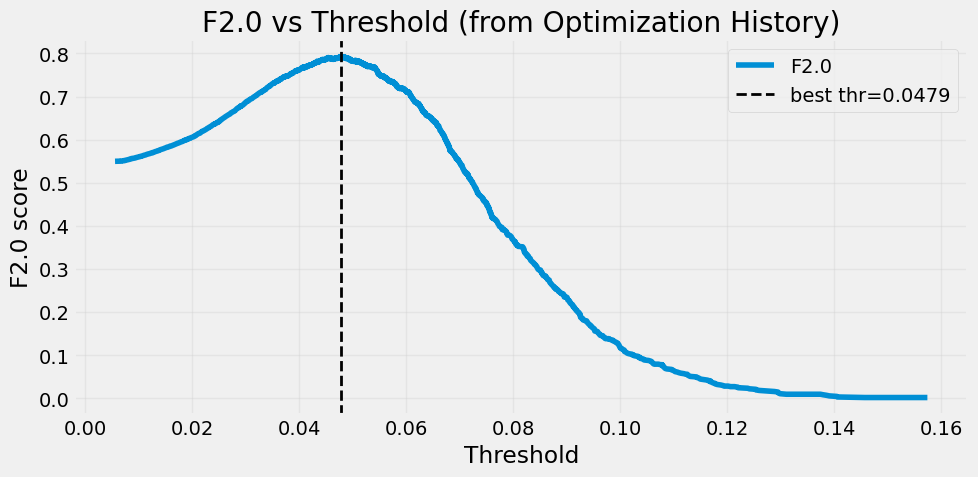

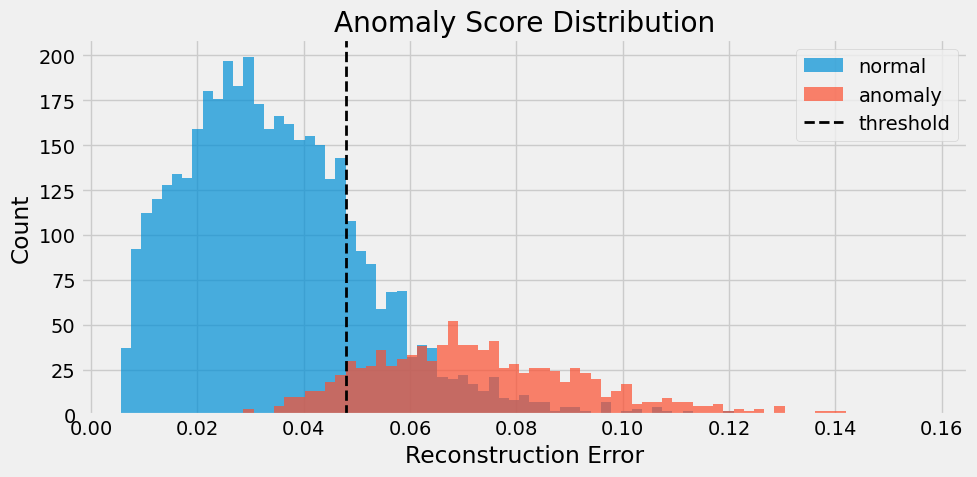

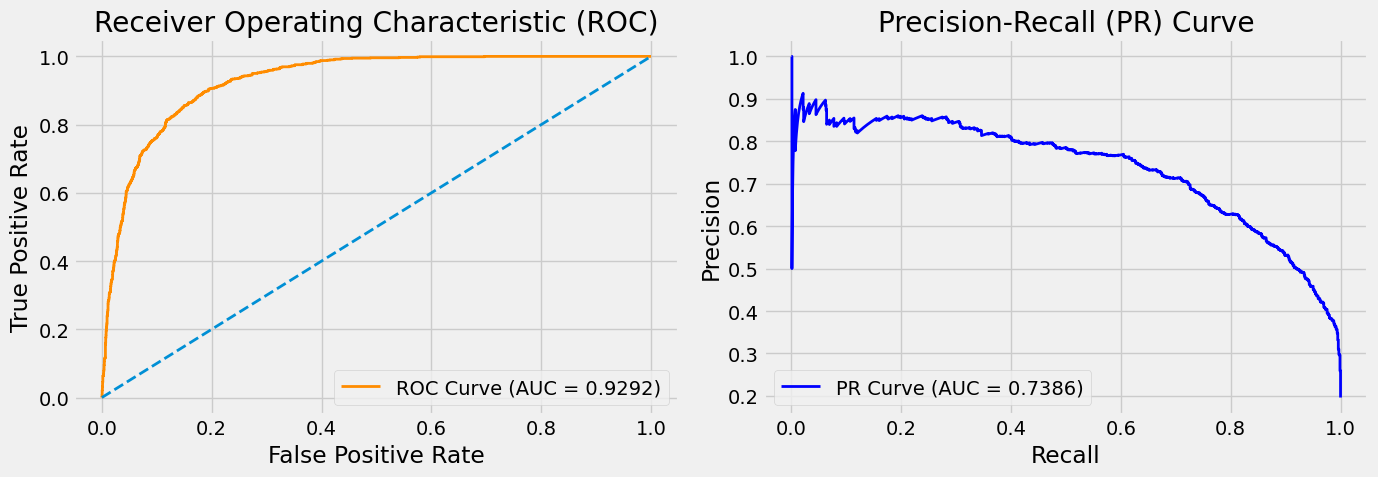

In [8]:
normal_scores = base_normal_scores + lambda_weight * var_normal_scores
anomaly_scores = base_anomaly_scores + lambda_weight * var_anomaly_scores

beta = 2.0
best_threshold, best_results = optimize_fbeta_threshold(
    val_normal_scores=normal_scores,
    val_anomaly_scores=anomaly_scores,
    beta = beta
)

print_metrics(
    y_true = best_results["y_true"],
    y_scores = best_results["y_scores"],
    threshold = best_threshold,
    beta = beta
)

plot_fbeta_vs_threshold(best_results['thresholds'], best_results['fbeta_vals'], best_threshold, beta, save_path=SAVE_DIR / f"eval_f{beta}_vs_threshold.png")
plot_anomaly_distribution(normal_scores, anomaly_scores, best_threshold, save_path=SAVE_DIR / "eval_anomaly_score_distribution.png")
plot_performance_curves(best_results["y_true"], best_results["y_scores"], save_path=SAVE_DIR / "eval_performance_curves.png")

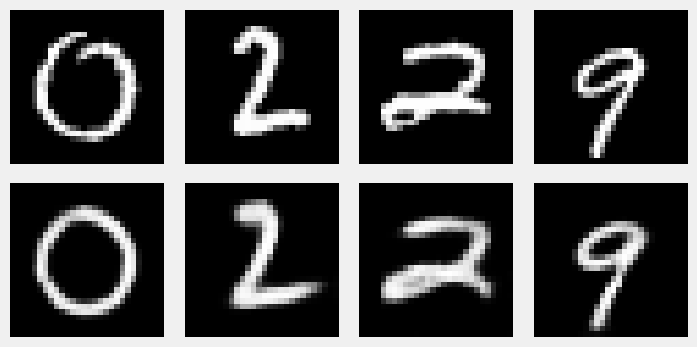

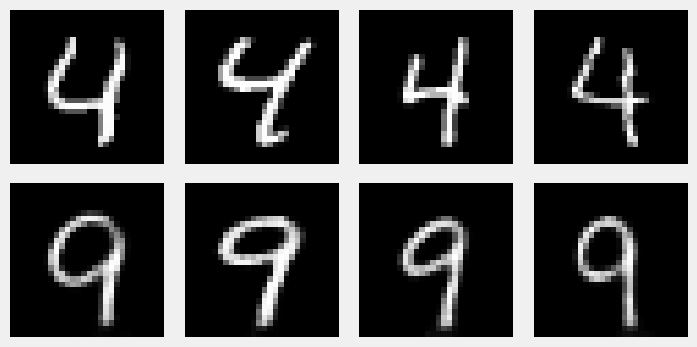

In [9]:
test_normal_og, test_normal_rec = get_reconstructions(model, test_normal[0][:4], device)
test_anomaly_og, test_anomaly_rec = get_reconstructions(model, test_anomaly[0][:4], device)

# Reconstruction examples for test_normal
plot_reconstructions(test_normal_og, test_normal_rec, '', save_path=SAVE_DIR / 'test_rec_test_normal.png')

# Reconstruction examples for test_anomaly
plot_reconstructions(test_anomaly_og, test_anomaly_rec, '', save_path=SAVE_DIR / 'test_rec_test_anomaly.png')